In [1]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================
import re
import html
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# SASTRAWI (INDONESIAN STEMMER)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import gensim.downloader as api
from tqdm import tqdm


# =====================================================
# 2. LOAD FASTTEXT INDONESIA (cc.id.300)
# =====================================================
print("Loading FastText model...")
fasttext = api.load('fasttext-wiki-news-subwords-300')
print("FastText loaded!")


# =====================================================
# 3. STOPWORDS & STEMMER SETUP (SASTRAWI)
# =====================================================
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}

final_stopwords = stop_words_id - protected_stopwords


# =====================================================
# 4. PREPROCESSING & EMBEDDING FUNCTIONS
# =====================================================
def preprocess_text(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    # Stopword removal
    tokens = [t for t in tokens if t not in final_stopwords]

    # Sastrawi stemming (mengganti WordNet lemmatization)
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens


def document_vector(tokens, model, vector_size=300):
    vectors = [model[w] for w in tokens if w in model]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)


def vectorize_series(text_series):
    return np.vstack(text_series.apply(
        lambda x: document_vector(preprocess_text(x), fasttext)
    ))


# =====================================================
# 5. MODEL FACTORY (TANPA TRAINING)
# =====================================================
def build_stacking_model():
    base_learners = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svm', SVC(probability=True))
    ]

    meta_learner = LogisticRegression(max_iter=1000)

    return StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5
    )


# =====================================================
# FASTTEXT VECTORIZATION WITH PROGRESS BAR
# =====================================================
def vectorize_series_with_progress(text_series, desc="Vectorizing"):
    vectors = []

    for text in tqdm(text_series, desc=desc):
        if not isinstance(text, str):
            text = ""

        tokens = preprocess_text(text)
        vectors.append(document_vector(tokens, fasttext))

    return np.vstack(vectors)

Loading FastText model...
FastText loaded!


In [ ]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# =============================
# 1. LOAD DATASET HPT
# =============================
dataset_hpt_full = pd.read_csv("Dataset Steve.csv")
dataset_hpt_full = dataset_hpt_full[['Text', 'label']]
dataset_hpt_full = dataset_hpt_full.dropna(subset=['Text', 'label'])

# =============================
# 2. STRATIFIED SUBSET
# =============================
MAX_HPT_SAMPLES = 6000
RANDOM_STATE = 42

label_props = dataset_hpt_full['label'].value_counts(normalize=True)

subset_parts = []
for label, prop in label_props.items():
    n_samples = max(1, int(prop * MAX_HPT_SAMPLES))
    subset_parts.append(
        dataset_hpt_full[dataset_hpt_full['label'] == label]
        .sample(n=n_samples, random_state=RANDOM_STATE)
    )

dataset_hpt = (
    pd.concat(subset_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_hpt_text = dataset_hpt['Text']
y_hpt = dataset_hpt['label']

# =============================
# 3. VECTORIZE
# =============================
X_hpt = vectorize_series(X_hpt_text)

# =============================
# 4. STACKING MODEL
# =============================
base_learners = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True))
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1
)

# =============================
# 5. PARAM GRID
# =============================
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 20, 40],
    'rf__min_samples_split': [2, 5],
    'svm__C': [0.1, 1, 10],
    'final_estimator__C': [0.1, 1, 10]
}

# =============================
# 6. GRID SEARCH (MULTI METRIC)
# =============================
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'auc': 'roc_auc'
}

grid_search = GridSearchCV(
    estimator=stacking_model,
    param_grid=param_grid,
    scoring=scoring,
    refit='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("🚀 Running Hyperparameter Tuning...")
grid_search.fit(X_hpt, y_hpt)

# =============================
# 7. AMBIL HASIL TERBAIK
# =============================
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_hpt)
y_prob = best_model.predict_proba(X_hpt)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_hpt, y_pred),
    "precision": precision_score(y_hpt, y_pred),
    "recall": recall_score(y_hpt, y_pred),
    "f1_score": f1_score(y_hpt, y_pred),
    "auc": roc_auc_score(y_hpt, y_prob)
}

print("\n✅ Evaluation Metrics (HPT Subset)")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# =============================
# 8. SAVE KE JSON
# =============================
hpt_result = {
    "best_params": grid_search.best_params_,
    "cv_best_f1": grid_search.best_score_,
    "metrics_on_hpt_subset": metrics
}

with open("hyperparameters_ensemble.json", "w") as f:
    json.dump(hpt_result, f, indent=4)

print("\n💾 Saved to hyperparameters_ensemble.json")


🚀 Running Hyperparameter Tuning...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

✅ Evaluation Metrics (HPT Subset)
accuracy: 0.9403
precision: 0.9253
recall: 0.7474
f1_score: 0.8269
auc: 0.9919

💾 Saved to hyperparameters_ensemble.json


In [2]:
# =====================================================
# 7. FINAL TRAINING (WITH MONITORING)
# =====================================================

from sklearn.model_selection import train_test_split
import json
import numpy as np
import pandas as pd

dataset_a = pd.read_csv('smote_100.csv')
dataset_b = pd.read_csv('data_20.csv')

X_a = dataset_a['Text']
y_a = dataset_a['label']

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_a, y_a,
    test_size=0.125,
    random_state=42,
    stratify=y_a
)

# 🔥 PROGRESS BAR DI SINI
X_train = vectorize_series_with_progress(X_train_text, desc="Vectorizing TRAIN")
X_val   = vectorize_series_with_progress(X_val_text, desc="Vectorizing VAL")
X_test  = vectorize_series_with_progress(dataset_b['Text'], desc="Vectorizing TEST")

y_test = dataset_b['label']

# =============================
# LOAD BEST PARAMS
# =============================
with open("hyperparameters_ensemble.json", "r") as f:
    hpt_result = json.load(f)

BEST_PARAMS = hpt_result["best_params"]

final_model = build_stacking_model()
final_model.set_params(**BEST_PARAMS)

# =============================
# TRAIN FINAL MODEL
# =============================
X_final = np.vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

print("🚀 Training final stacking model...")
final_model.fit(X_final, y_final)
print("✅ Training completed")

# =====================================================
# 8. FINAL EVALUATION
# =====================================================
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print('\n=== FINAL TEST EVALUATION ===')
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))
print('AUC      :', roc_auc_score(y_test, y_proba))

Vectorizing TEST: 100%|██████████| 3523/3523 [02:51<00:00, 20.54it/s]


🚀 Training final stacking model...
✅ Training completed

=== FINAL TEST EVALUATION ===
Accuracy : 0.8912858359352824
Precision: 0.6960651289009498
Recall   : 0.7633928571428571
F1-score : 0.7281760113555713
AUC      : 0.9121444438876919


=== CLASSIFICATION REPORT (PER LABEL) ===
              precision    recall  f1-score   support

     Label 0     0.9429    0.9214    0.9321      2851
     Label 1     0.6961    0.7634    0.7282       672

    accuracy                         0.8913      3523
   macro avg     0.8195    0.8424    0.8301      3523
weighted avg     0.8958    0.8913    0.8932      3523

=== CONFUSION MATRIX ===
[[2627  224]
 [ 159  513]]


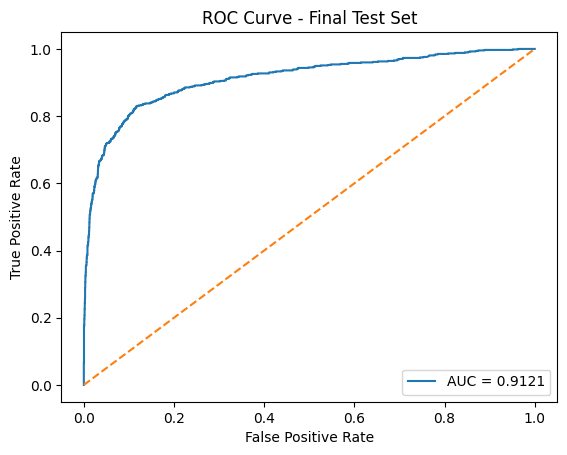

In [3]:
# =====================================================
# DETAILED EVALUATION: PER-CLASS + ROC CURVE
# =====================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# =============================
# 1. PER-CLASS METRICS
# =============================
print("=== CLASSIFICATION REPORT (PER LABEL) ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Label 0", "Label 1"],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

# =============================
# 2. ROC CURVE
# =============================
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set")
plt.legend(loc="lower right")
plt.show()
